In [1]:
import json
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from tqdm import tqdm
from pathlib import Path
import warnings
import copy
import csv

from sklearn.exceptions import UndefinedMetricWarning
warnings.filterwarnings("ignore", category=UndefinedMetricWarning)

np.random.seed(42)
torch.manual_seed(42)
device = "cuda" if torch.cuda.is_available() else "cpu"

# Paths
ROOT = Path("Amazon_products")
TRAIN_CORPUS_PATH = ROOT / "train" / "train_corpus.txt"
TEST_CORPUS_PATH  = ROOT / "test" / "test_corpus.txt"
CLASS_PATH        = ROOT / "classes.txt"

EMB_DIR      = Path("SilverGeneration/Embeddings")
X_ALL_PATH   = EMB_DIR / "X_train_test_mpnet.pt" # Train + Test embeddings
LABEL_EMB_PATH = EMB_DIR / "labels_mpnet.pt"

MODEL_SAVE = Path("Models")
MODEL_SAVE.mkdir(exist_ok=True)
MODEL_PATH = MODEL_SAVE / "classifierMIX.pt"

# Load useful data (like silver gen)
def load_classic(path):
    id2text = {}
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            pid, text = line.strip().split("\t", 1)
            id2text[int(pid)] = text
    return id2text

id2text_train = load_classic(TRAIN_CORPUS_PATH)
id2text_test  = load_classic(TEST_CORPUS_PATH)
train_ids = list(id2text_train.keys())
test_ids  = list(id2text_test.keys())
n_train = len(train_ids)
n_test  = len(test_ids)
print(f"Train IDs: {n_train} | Test IDs: {n_test}")

# Load silver label (hier & nohier)
with open("SilverGeneration/SilverCombo/silver_train_mpnet.json", "r", encoding="utf-8") as f:
    raw = json.load(f)
silver_labels = {int(pid): data["labels"] for pid, data in raw.items()}

# Load X_all + split into X_train & X_test
data = torch.load(X_ALL_PATH, weights_only=False)

# ensure tensor (check)
if isinstance(data, np.ndarray):
    data = torch.from_numpy(data)
elif isinstance(data, list):
    data = torch.stack(data)

X_all = data.float().to(device)
X_train = X_all[:n_train]
X_test  = X_all[n_train:]
print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")

# Load Class names
classes = {}
with open(CLASS_PATH, "r", encoding="utf-8") as f:
    for line in f:
        cid, cname = line.strip().split("\t")
        classes[int(cid)] = cname

n_classes = len(classes) # 531
print(n_classes)

pid2idx = {pid: i for i, pid in enumerate(train_ids)}


Train IDs: 29487 | Test IDs: 19658
X_train: torch.Size([29487, 768]), X_test: torch.Size([19658, 768])
531


In [2]:
class MultiLabelDataset(Dataset):
    """
    Simple PyTorch dataset for multi-label classification.
    Takes a list of product IDs and a dict pid -> list of labels,
    and returns (embedding, multi-hot label vector) for each item.
    """
    def __init__(self, pids, labels_dict):
        self.pids = pids
        self.labels = labels_dict

    def __len__(self):
        return len(self.pids)

    def __getitem__(self, idx):
        pid = self.pids[idx]
        emb = X_train[pid2idx[pid]]

        y = torch.zeros(n_classes)
        for c in self.labels[pid]:
            if 0 <= c < n_classes:
                y[c] = 1.0 # one-hot multi-label vector

        return {"X": emb, "y": y}

# TRAIN / VAL splits
train_p, val_p = train_test_split(list(silver_labels.keys()),test_size=0.2,random_state=42)

train_dataset = MultiLabelDataset(train_p, silver_labels)
val_dataset   = MultiLabelDataset(val_p,   silver_labels)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=64)


In [3]:
# Evaluation metrics -> see paper given
def precision_at_1(y_true, scores):
    """
    Computes Precision@1 for multi-label classification.
    For each sample, we check if the top-1 predicted class is actually a true label.
    """
    correct = 0
    for yt, sc in zip(y_true, scores):
        top1 = sc.argmax()
        if yt[top1] == 1:
            correct += 1
    return correct / len(y_true)


def precision_at_3(y_true, scores):
    """
    Computes Precision@3 for multi-label classification.
    For each sample, we check how many of the top-3 predicted classes
    match the true labels, and average over all samples.
    """
    total_correct = 0
    for yt, sc in zip(y_true, scores):
        top3 = sc.argsort()[-3:][::-1]   # indices of best 3 scores
        total_correct += yt[top3].sum()
    return total_correct / (3 * len(y_true))


In [4]:
# See Assignment 4

class LabelGCN(nn.Module):
    """
    Lightweight GCN encoder for refining label embeddings.
    Applies message passing over the label graph with residual connections.
    """
    def __init__(self, emb_dim, num_layers=1, dropout=0.5):
        super().__init__()
        self.emb_dim = emb_dim
        self.num_layers = num_layers
        self.dropout = dropout

        # Linear transforms for each GCN layer
        self.W_list = nn.ParameterList()
        for _ in range(num_layers):
            W = nn.Parameter(torch.empty(emb_dim, emb_dim))
            nn.init.xavier_uniform_(W)
            self.W_list.append(W)

    def forward(self, H, A_hat):
        """
        H: label embeddings (C, D)
        A_hat: normalized adjacency (C, C)
        """
        for i, W in enumerate(self.W_list):
            H_input = H  # residual connection

            # Message passing: A_hat H W
            H_msg = A_hat @ H_input
            H_msg = H_msg @ W

            # Residual update (skip connection)
            H = H_input + H_msg

            # Non-linearity + dropout on intermediate layers only
            if i < self.num_layers - 1:
                H = F.relu(H)
                H = F.dropout(H, p=self.dropout, training=self.training)

        return H


class GCNEnhancedClassifier(nn.Module):
    """
    Document classifier using:
      1) GCN-refined label embeddings
      2) Projection of document embeddings
      3) Scaled cosine similarity for logits
    """
    def __init__(self, input_dim, label_init_emb, A_hat, num_layers=1, dropout=0.2):
        super().__init__()
        emb_dim = label_init_emb.size(1)

        # Project document embedding -> label embedding space
        self.proj = nn.Linear(input_dim, emb_dim)
        self.dropout = dropout

        # GCN for refining label embeddings
        self.encoder = LabelGCN(emb_dim, num_layers=num_layers, dropout=dropout)

        # Trainable label embeddings
        self.label_emb = nn.Parameter(label_init_emb.clone())

        # Store adjacency matrix (not trainable)
        self.register_buffer("A_hat", A_hat)

    def forward(self, x, use_dropout=True):
        """
        x: document embeddings (B, D_doc)
        Returns: logits (B, C)
        """
        # GCN refinement of label embeddings
        E_refine = self.encoder(self.label_emb, self.A_hat)   # (C, D)

        # Project document embeddings
        x_proj = self.proj(x)
        if use_dropout:
            x_proj = F.dropout(x_proj, p=self.dropout, training=self.training)

        # Normalize for cosine similarity (more stable than raw inner product and
        # ensures predictions depend on direction rather than vector magnitude)
        x_proj = F.normalize(x_proj, dim=1)
        E_refine = F.normalize(E_refine, dim=1)

        # Scaled cosine logits (for loss)
        logits = (x_proj @ E_refine.T) * 30.0 
        return logits


In [5]:
def build_adj_from_hierarchy(class2hierarchy, n_classes):
    """
    Build adjacency matrix for a hierarchical label graph.
    parent–child connections
    """
    A = torch.zeros((n_classes, n_classes))
    w_parent = 1.0

    # Add parent <-> child edges
    for parent, children in class2hierarchy.items():
        for c in children:
            A[parent, c] = w_parent
            A[c, parent] = w_parent

    # Add self-loops
    A = A + torch.eye(n_classes)

    # GCN normalization: D^{-1/2} A D^{-1/2}
    D = A.sum(dim=1)
    D_inv_sqrt = torch.pow(D, -0.5)
    D_inv_sqrt[torch.isinf(D_inv_sqrt)] = 0.0
    D_mat = torch.diag(D_inv_sqrt)

    A_hat = D_mat @ A @ D_mat
    return A_hat

def load_multilabel(path):
    """Load multi-label data into {id: [labels]} dictionary -> for class_hierarchy"""
    id2labels = {}
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            parts = line.strip().split("\t")
            if len(parts) == 2:
                pid, label = parts
                pid = int(pid)
                label = int(label)
                if pid not in id2labels:
                    id2labels[pid] = []
                id2labels[pid].append(label)
    return id2labels

In [6]:
CLASS_HIERARCHY_PATH = ROOT / "class_hierarchy.txt"
class2hierarchy = load_multilabel(CLASS_HIERARCHY_PATH)

A_hat = build_adj_from_hierarchy(class2hierarchy, n_classes).to(device)

print("A_hat:", A_hat.shape, "Non-zero =", (A_hat > 0).sum().item())

label_emb = torch.load(LABEL_EMB_PATH).float().to(device)
print("Label embeddings:", label_emb.shape)

A_hat: torch.Size([531, 531]) Non-zero = 1667
Label embeddings: torch.Size([531, 768])


In [7]:
class InnerProductClassifier(nn.Module):
    """
    A simple classifier that projects input embeddings and
    scores each label via inner product with its embedding.
    """
    def __init__(self, input_dim, label_embeddings, dropout=0.2, trainable_label_emb=False):
        super().__init__()

        D = label_embeddings.size(1)

        self.proj = nn.Linear(input_dim, D)
        self.dropout = nn.Dropout(dropout)

        # Label embeddings can be fixed or trainable (for innerproduct we'll prefer fixed cause 
        # it preserves semantic meaning from pretrained embeddings and reduces overfitting risk 
        # on noisy silver labels)        
        if trainable_label_emb:
            self.label_emb = nn.Parameter(label_embeddings.clone())
        else:
            self.register_buffer("label_emb", label_embeddings.clone())

    def forward(self, x, use_dropout=True):
        # project input
        x_proj = self.proj(x)
        
        if use_dropout:
            x_proj = self.dropout(x_proj)
        
        # normalize
        x_proj = F.normalize(x_proj, dim=1)
        label_emb = F.normalize(self.label_emb, dim=1)
        
        # Scale to expand sigmoid range: normalized inner products ∈ [-1,1] → need scaling for confident predictions
        logits = (x_proj @ label_emb.T) * 30.0
        return logits


In [8]:
def consistency_loss(log_s, log_t):
    """MSE between teacher/student probabilities"""
    ps = torch.sigmoid(log_s)
    pt = torch.sigmoid(log_t)
    return F.mse_loss(ps, pt)

def bce_with_logits_smooth(logits, targets, smoothing=0.05):
    """
    BCE with logits + label smoothing.
    Helps reduce overconfident predictions and improves stability.
    """
    targets = targets * (1 - smoothing) + 0.5 * smoothing
    return F.binary_cross_entropy_with_logits(logits, targets)

class EnsembleModel(nn.Module):
    # Combine gnn & inner
    def __init__(self, model_gcn, model_inner):
        super().__init__()
        self.gcn = model_gcn
        self.inner = model_inner

    def forward(self, x):
        log_gcn = self.gcn(x)
        log_in = self.inner(x)
        return (log_gcn + log_in) / 2.0    # ensemble logits

In [9]:
# Add of scheduler and weight decay (ensemble GCN + InnerProduct)

dropout = 0.4
model_gcn   = GCNEnhancedClassifier(X_train.size(1), label_emb, A_hat, 2, dropout).to(device)
model_inner = InnerProductClassifier(X_train.size(1), label_emb, dropout).to(device)

optimizer_gcn   = torch.optim.AdamW(model_gcn.parameters(), lr=1e-4, weight_decay=2e-3)
optimizer_inner = torch.optim.AdamW(model_inner.parameters(), lr=1e-4, weight_decay=2e-3)

scheduler_gcn   = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer_gcn, T_0=10, T_mult=2, eta_min=5e-6)
scheduler_inner = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer_inner, T_0=10, T_mult=2, eta_min=5e-6)

val_f1_list = []
val_p1_list = []
val_p3_list = []
epochs = 150
patience = 10
wait = 0

best_f1 = 0
best_state_gcn   = None
best_state_inner = None

for epoch in range(1, epochs+1):
    model_gcn.train()
    model_inner.train()
    total_loss_gcn = 0
    total_loss_inner = 0

    for batch in tqdm(train_loader, desc=f"Epoch {epoch}/{epochs}"):
        X = batch["X"].to(device)
        y = batch["y"].to(device)

        # GCN forward
        logits_gcn = model_gcn(X)
        # Loss with label smoothing:
        # We use label smoothing to prevent the model from becoming overly confident.
        loss_gcn = bce_with_logits_smooth(logits_gcn, y, smoothing=0.05)

        optimizer_gcn.zero_grad()
        loss_gcn.backward()
        optimizer_gcn.step()
        total_loss_gcn += loss_gcn.item()

        # InnerProduct forward
        logits_inner = model_inner(X)
        # Loss with label smoothing:
        loss_inner = bce_with_logits_smooth(logits_inner, y, smoothing=0.05)

        optimizer_inner.zero_grad()
        loss_inner.backward()
        optimizer_inner.step()
        total_loss_inner += loss_inner.item()

    scheduler_gcn.step()
    scheduler_inner.step()

    # Ensemble Validation
    model_gcn.eval()
    model_inner.eval()

    preds, labels = [], []
    all_scores, all_true = [], []

    with torch.no_grad():
        for batch in val_loader:
            X = batch["X"]
            y = batch["y"].numpy()

            # Ensemble: average logits
            logits_ens = (model_gcn(X) + model_inner(X)) / 2.0
            prob = torch.sigmoid(logits_ens).cpu().numpy()

            pred = (prob > 0.20).astype(int)     # Threshold evaluation (middle thr between the one that we used for inner and the one used for gnn)
            preds.extend(pred)
            labels.extend(y)

            all_scores.extend(prob)
            all_true.extend(y)

    # Metrics
    f1s = f1_score(labels, preds, average="samples")
    f1m = f1_score(labels, preds, average="macro")
    P1  = precision_at_1(all_true, all_scores)
    P3  = precision_at_3(all_true, all_scores)

    val_f1_list.append(f1s)
    val_p1_list.append(P1)
    val_p3_list.append(P3)

    print(f"[Epoch {epoch}] GCN loss={total_loss_gcn/len(train_loader):.4f} | "
          f"Inner loss={total_loss_inner/len(train_loader):.4f} | F1={f1s:.4f}")

    # Save best model
    if f1s > best_f1:
        best_f1 = f1s
        wait = 0
        best_state_gcn   = copy.deepcopy(model_gcn.state_dict())
        best_state_inner = copy.deepcopy(model_inner.state_dict())
        torch.save({"gcn": best_state_gcn, "inner": best_state_inner}, MODEL_PATH)
        print(f"New best model saved ({best_f1:.4f})")
    else:
        wait += 1
        if wait >= patience:
            print("\nEarly stopping triggered")
            break

print(f"\nBest validation F1 = {best_f1:.4f}")
print(f"Model saved at: {MODEL_PATH}")

# Reload both best states
model_gcn.load_state_dict(best_state_gcn)
model_inner.load_state_dict(best_state_inner)


Epoch 1/150: 100%|██████████| 220/220 [00:02<00:00, 90.73it/s] 


[Epoch 1] GCN loss=0.1530 | Inner loss=0.1542 | F1=0.0006
New best model saved (0.0006)


Epoch 2/150: 100%|██████████| 220/220 [00:01<00:00, 130.77it/s]


[Epoch 2] GCN loss=0.1345 | Inner loss=0.1376 | F1=0.0998
New best model saved (0.0998)


Epoch 3/150: 100%|██████████| 220/220 [00:01<00:00, 129.96it/s]


...

Epoch 149/150: 100%|██████████| 220/220 [00:01<00:00, 120.39it/s]


[Epoch 149] GCN loss=0.1218 | Inner loss=0.1280 | F1=0.7994


Epoch 150/150: 100%|██████████| 220/220 [00:01<00:00, 114.29it/s]


[Epoch 150] GCN loss=0.1218 | Inner loss=0.1280 | F1=0.7982

Best validation F1 = 0.7996
Model saved at: Models\classifierMIX.pt


<All keys matched successfully>

In [10]:
import matplotlib.pyplot as plt

def plot_all_metrics(results_dict):
    """
    Similar to plot from utils.py
    Plot F1, P@1, and P@3 curves for 2 models.

    results_dict must be of form:
    {
        "F1": {"Model 1": [...], "Model 2": [...]},
        "P@1": {"Model 1": [...], "Model 2": [...]},
        "P@3": {"Model 1": [...], "Model 2": [...]},
    }
    """

    metrics = ["F1", "P@1", "P@3"]
    plt.figure(figsize=(16, 4))

    for i, metric in enumerate(metrics):
        plt.subplot(1, 3, i+1)
        for model_name, values in results_dict[metric].items():
            plt.plot(values, label=model_name)

        plt.title(metric + " over epochs")
        plt.xlabel("Epoch")
        plt.ylabel(metric)
        plt.grid(True)
        plt.legend()

    plt.tight_layout()
    plt.show()



Graph


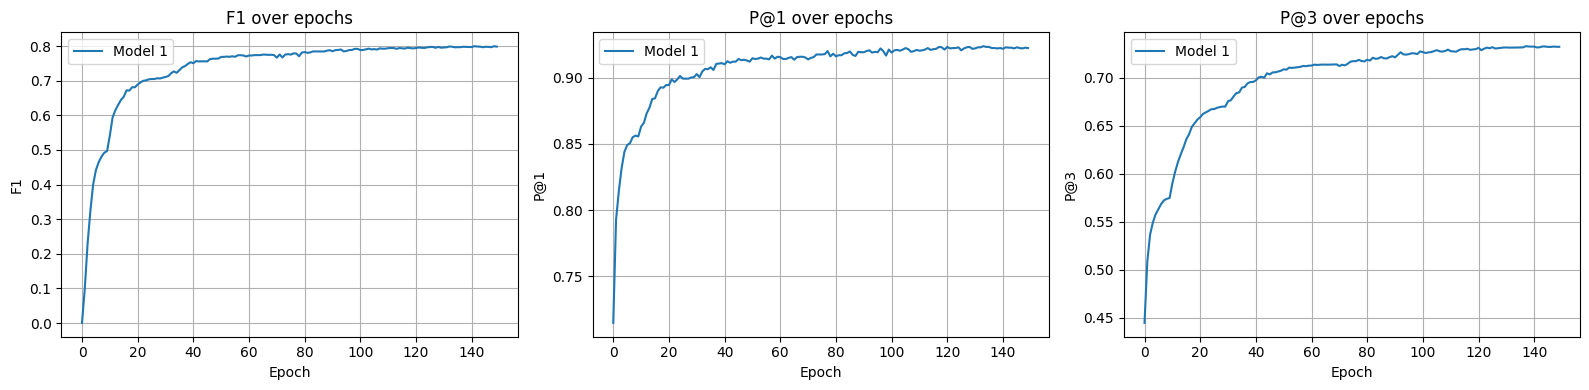

In [11]:
results = {
    "F1": {
        "Model 1": val_f1_list,
    },
    "P@1": {
        "Model 1": val_p1_list,
    },
    "P@3": {
        "Model 1": val_p3_list,
    }
}

# Graphics
print("\nGraph")
plot_all_metrics(results)

In [12]:
# Submission step - Ensemble predictions

# loading test_ids
test_ids = []
with open(TEST_CORPUS_PATH, "r", encoding="utf-8") as f:
    for line in f:
        pid, _ = line.strip().split("\t", 1)
        test_ids.append(int(pid))
print(len(test_ids))

# X_all -> Train Id + Test Id
X_all = torch.load(X_ALL_PATH, weights_only=False)

# Check again (I had some pb with these types)
if isinstance(X_all, np.ndarray):
    X_all = torch.from_numpy(X_all)
elif isinstance(X_all, list):
    X_all = torch.stack(X_all)

X_all = X_all.float()
n_test = len(test_ids)
X_test = X_all[-n_test:]

# Model selection : top-2 / top-3
def select_k(prob, min_k=2, max_k=3):
    idx = np.argsort(prob)[::-1]     # top probs first
    top3 = idx[:max_k]
    # if the 3rd is too far from the 2nd -> keep only 2 labels
    if prob[top3[2]] < 0.33 * prob[top3[1]]:
        return top3[:2]
    return top3


# Ensemble prediction: GCN + InnerProduct
model_gcn.eval()
model_inner.eval()
X_test = X_test.to(device)

preds = []
batch_size = 64

with torch.no_grad():
    for start in tqdm(range(0, len(X_test), batch_size)):
        batch = X_test[start:start+batch_size]
        
        # Get predictions from both models
        logits_gcn = model_gcn(batch)
        logits_inner = model_inner(batch)
        
        # Ensemble: average logits
        logits_ensemble = (logits_gcn + logits_inner) / 2.0
        probs = torch.sigmoid(logits_ensemble).cpu().numpy()

        for p in probs:
            labels = select_k(p)                     
            preds.append([str(x) for x in labels]) 

# Save ensemble submission
OUT_DIR = Path("Submission")
OUT_DIR.mkdir(exist_ok=True)
OUT_PATH = OUT_DIR / "submission_ensemble.csv"

with open(OUT_PATH, "w", newline="", encoding="utf-8") as f:
    w = csv.writer(f)
    w.writerow(["id", "label"])
    for pid, labels in zip(test_ids, preds):
        w.writerow([pid, ",".join(labels)])

print(f"Submission saved -> {OUT_PATH}")

19658


100%|██████████| 308/308 [00:01<00:00, 290.98it/s]

Submission saved -> Submission\submission_ensemble.csv


In [13]:
# Comparison with real results

def load_csv_labels(path):
    """
    Load a CSV file formatted as:
    id,label1 label2 label3
    Returns {id: [labels]}
    """
    out = {}
    with open(path, "r", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for row in reader:
            pid = int(row["id"])
            labels = [int(x) for x in row["label"].replace(",", " ").split()]
            out[pid] = labels
    return out


def score_submission_csv(pred_path, gold_path):
    """
    Score a submission CSV using your GOLD CSV.
    Computes: F1 (samples), P@1, P@3
    """
    pred = load_csv_labels(pred_path)
    gold = load_csv_labels(gold_path)

    # Sorted IDs intersection
    ids = sorted(set(pred.keys()) & set(gold.keys()))

    num_classes = 531

    Y_true = []
    Y_pred = []
    Y_scores = []

    for pid in ids:
        true_vec  = np.zeros(num_classes)
        pred_vec  = np.zeros(num_classes)
        score_vec = np.zeros(num_classes)

        true_vec[gold[pid]] = 1
        pred_vec[pred[pid]] = 1
        score_vec[pred[pid]] = 1.0

        Y_true.append(true_vec)
        Y_pred.append(pred_vec)
        Y_scores.append(score_vec)

    f1s = f1_score(Y_true, Y_pred, average="samples")
    P1 = precision_at_1(Y_true, Y_scores)
    P3 = precision_at_3(Y_true, Y_scores)

    print(f"Sample F1 : {f1s:.4f}")
    print(f"P@1 : {P1:.2f}")
    print(f"P@3 : {P3:.2f}")

score_submission_csv(
    pred_path="Submission/submission_ensemble.csv",
    gold_path="Gold/gold.csv"
)

Sample F1 : 0.5867
P@1 : 0.80
P@3 : 0.53
